In [1]:
from math import *
import sys
import time

import numpy as np
from numpy.random import seed
from numpy.random import shuffle

import matplotlib.pyplot as plt

from scipy import signal
from scipy.stats import norm
from scipy.io.wavfile import read
from scipy.io import loadmat
from scipy.optimize import minimize_scalar

sys.path.append("..")
import Pylos_toolkit as PyT
import report_plotstyle

scaling = 10 ** (168./20)

# Script to characterise and parameterise Pylos noise data
- 201650198.**180129**090002.wav: 29 Jan 2018 09:00
- 201650198.**180131**105931.wav: 31 Jan 2018 11:00
- 201650198.**180131**085932.wav: 31 Jan 2018 09:00


## Define functions and load data

In [2]:
# Because I like to have clean notebooks
t, y, sampling_rate, filename = PyT.load_Pylos_data(filename="../201650198.180131085932.wav")

Sampling rate:          144000 Hz
Length of time series:  120 minutes
Length of output time series:  180 seconds


# Visualise a trace

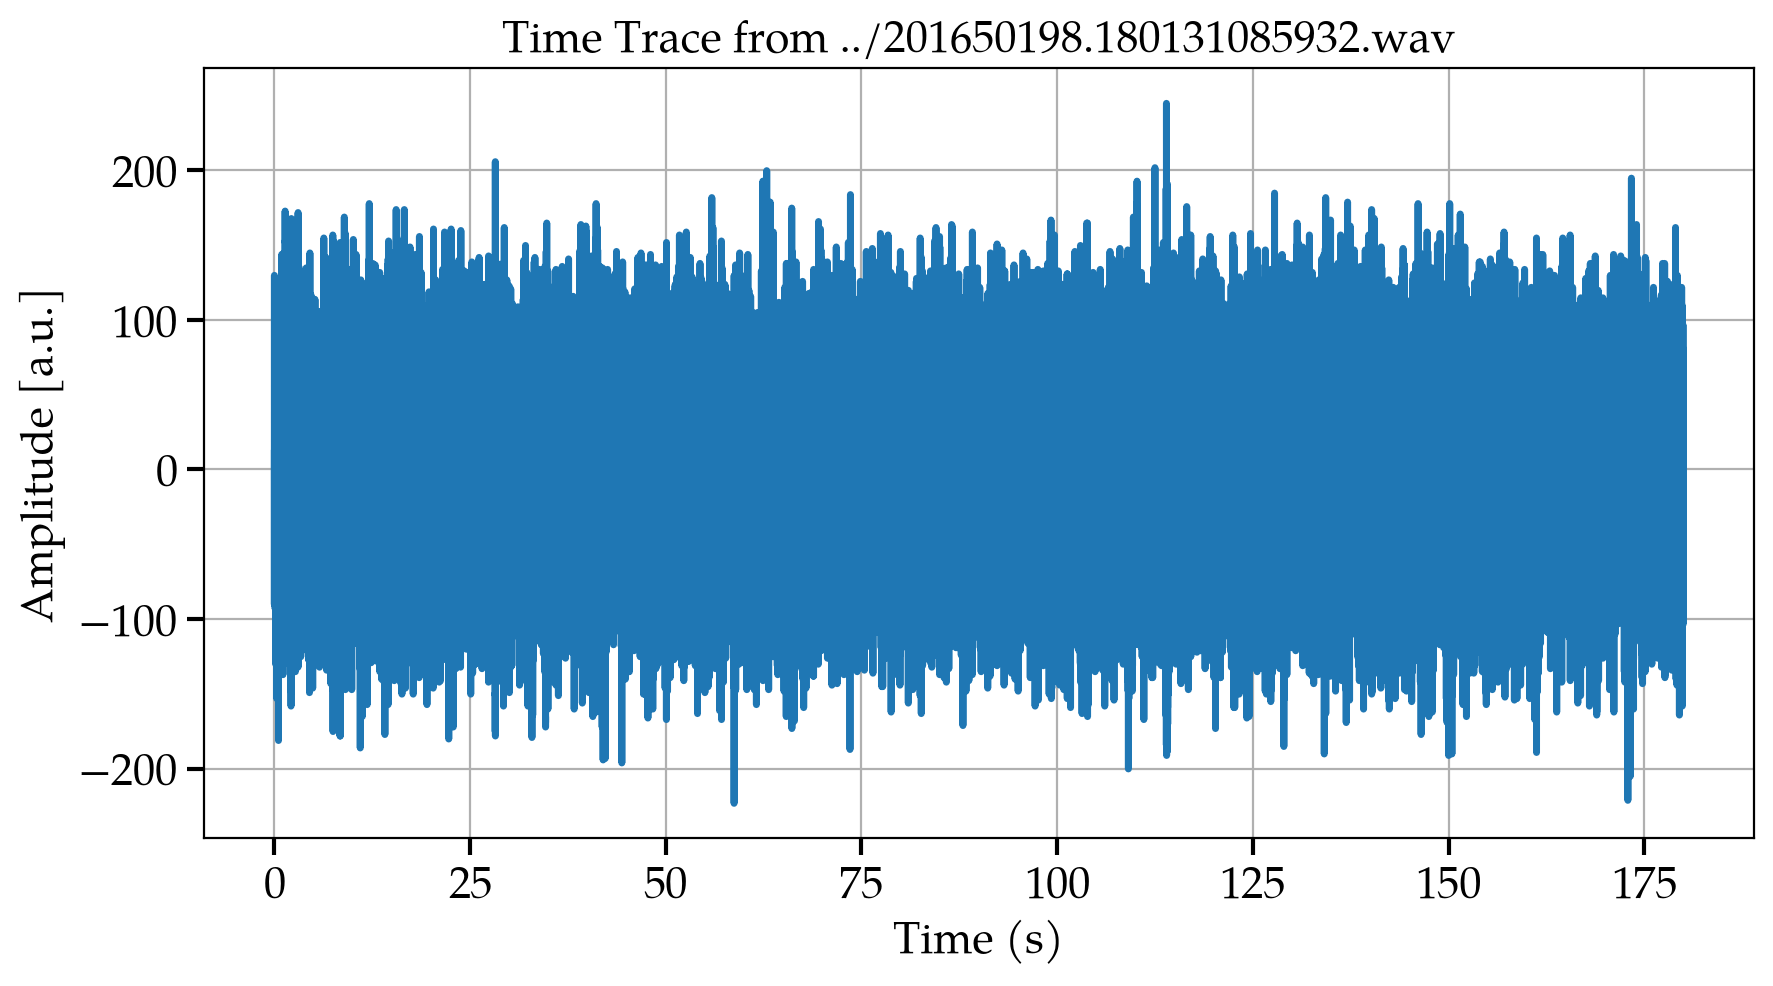

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(t, y, label='Time trace')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude [a.u.]')
plt.title(f'Time Trace from {filename}')
plt.grid()

# Plot spectrum
And fit to a Knudsen curve

In [4]:
# Take a smaller timetrace for the fits to limit runtime
trace_FFT_start = 0.  # [s]
trace_FFT_end   = 1. # [s]

i_FFT_start = int(trace_FFT_start * sampling_rate)
i_FFT_end   = int(trace_FFT_end * sampling_rate)

t_FFT = np.arange((i_FFT_end - i_FFT_start),dtype=float)
t_FFT /= sampling_rate

y_FFT = np.array(y[i_FFT_start : i_FFT_end],dtype=float)

# Processing
# y_FFT -= np.mean(y_FFT) # Remove DC offset

Optimal scaling factor: 4.60e+02


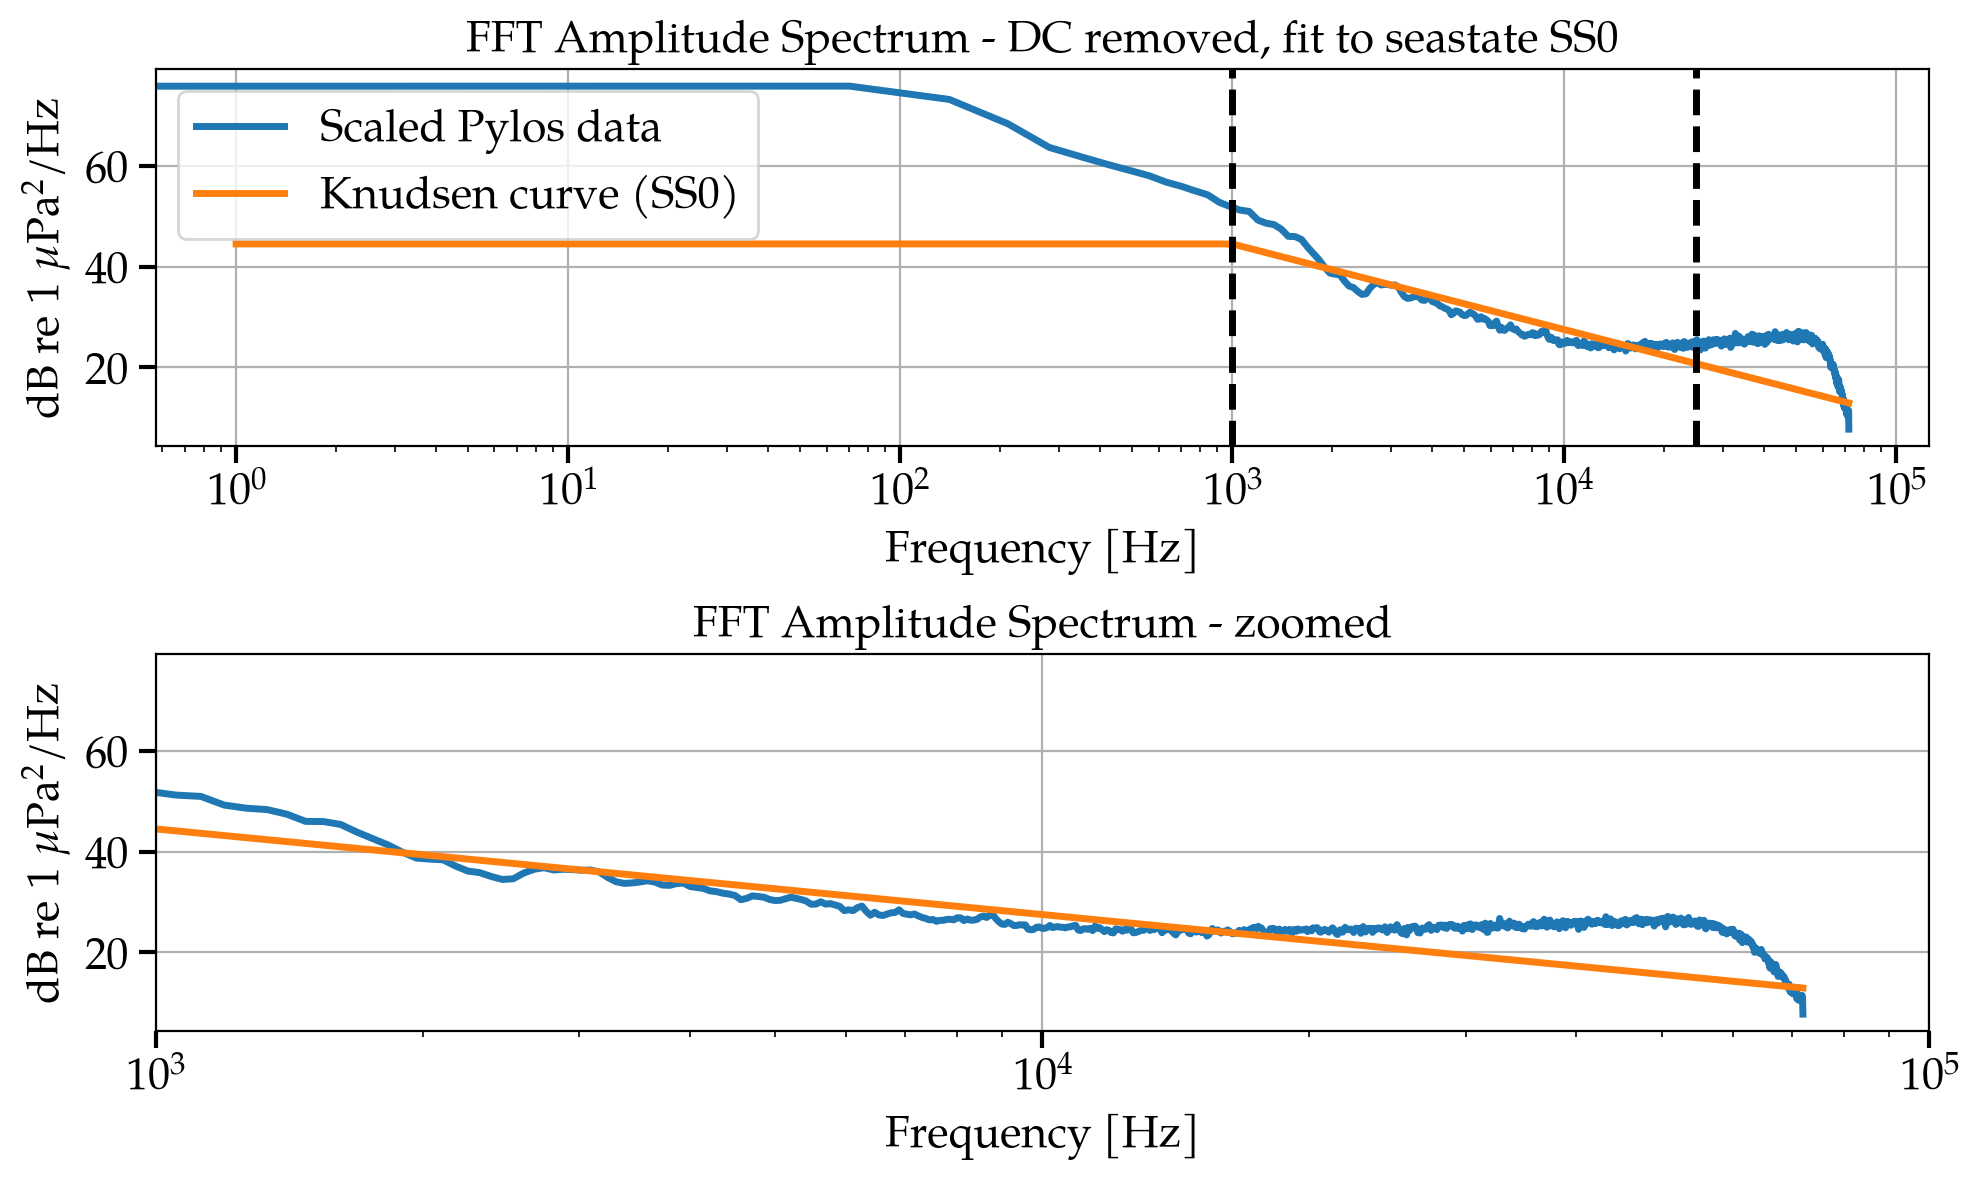

In [11]:
SS = 0

# Define frequency range for fitting
fmin          = 1000   # Hz
fmax          = 25000  # Hz
nperseg       = 2048

alpha_h, freqs  = PyT.time_domain_scaling_factor_from_SS_hanning(y_FFT, SS, sampling_rate=sampling_rate, fmin=fmin, fmax=fmax, nperseg=nperseg)
ycorr_h         = y_FFT  / alpha_h
print(f"Optimal scaling factor: {alpha_h:.2e}")

# Reference spectra & PSDs
freqs_ref             = np.linspace(1, 72000, 1000)
PSD_ss0               = PyT.Knudsen_curve(seastate=SS, frequency=freqs_ref)
PSD_therm             = PyT.Thermal_noise(freqs_ref)
PSD_tot               = PyT.add_PSDs(PSD_ss0, PSD_therm)
freqs_hann, m_dat     = signal.welch(ycorr_h, sampling_rate, nperseg=nperseg, scaling= 'density',window='hann')
p_dat                 = 10 * np.log10(m_dat * 1e12)   

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(freqs_hann, p_dat, label='Scaled Pylos data')
ax1.plot(freqs_ref, PSD_ss0, label=f'Knudsen curve (SS{SS})')
# ax1.plot(freqs_ref, PSD_tot, label=f'Knudsen curve + Thermal noise')
ax1.set_title(f'FFT Amplitude Spectrum - DC removed, fit to seastate SS{SS}')
ax1.set_xlabel('Frequency [Hz]')
ax1.axvline(1e3, color='k', linestyle='--')
ax1.axvline(25e3, color='k', linestyle='--')
# ax1.set_xlim([0, 72e3])
ax1.set_xscale('log')
ax1.legend()
ax1.set_ylabel('dB re 1 $\mu$Pa$^2$/Hz')
ax1.grid()

ax2.plot(freqs_hann, p_dat)
ax2.plot(freqs_ref, PSD_ss0, label=f'Knudsen curve (SS{SS})')
ax2.set_title('FFT Amplitude Spectrum - zoomed')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_xscale('log')
ax2.set_ylabel('dB re 1 $\mu$Pa$^2$/Hz')
ax2.set_xlim(1e3, 1e5)
# ax2.set_xlim(32600, 32800)
ax2.grid()
plt.tight_layout()
plt.show()


# Insert pulse

(2048, 2)


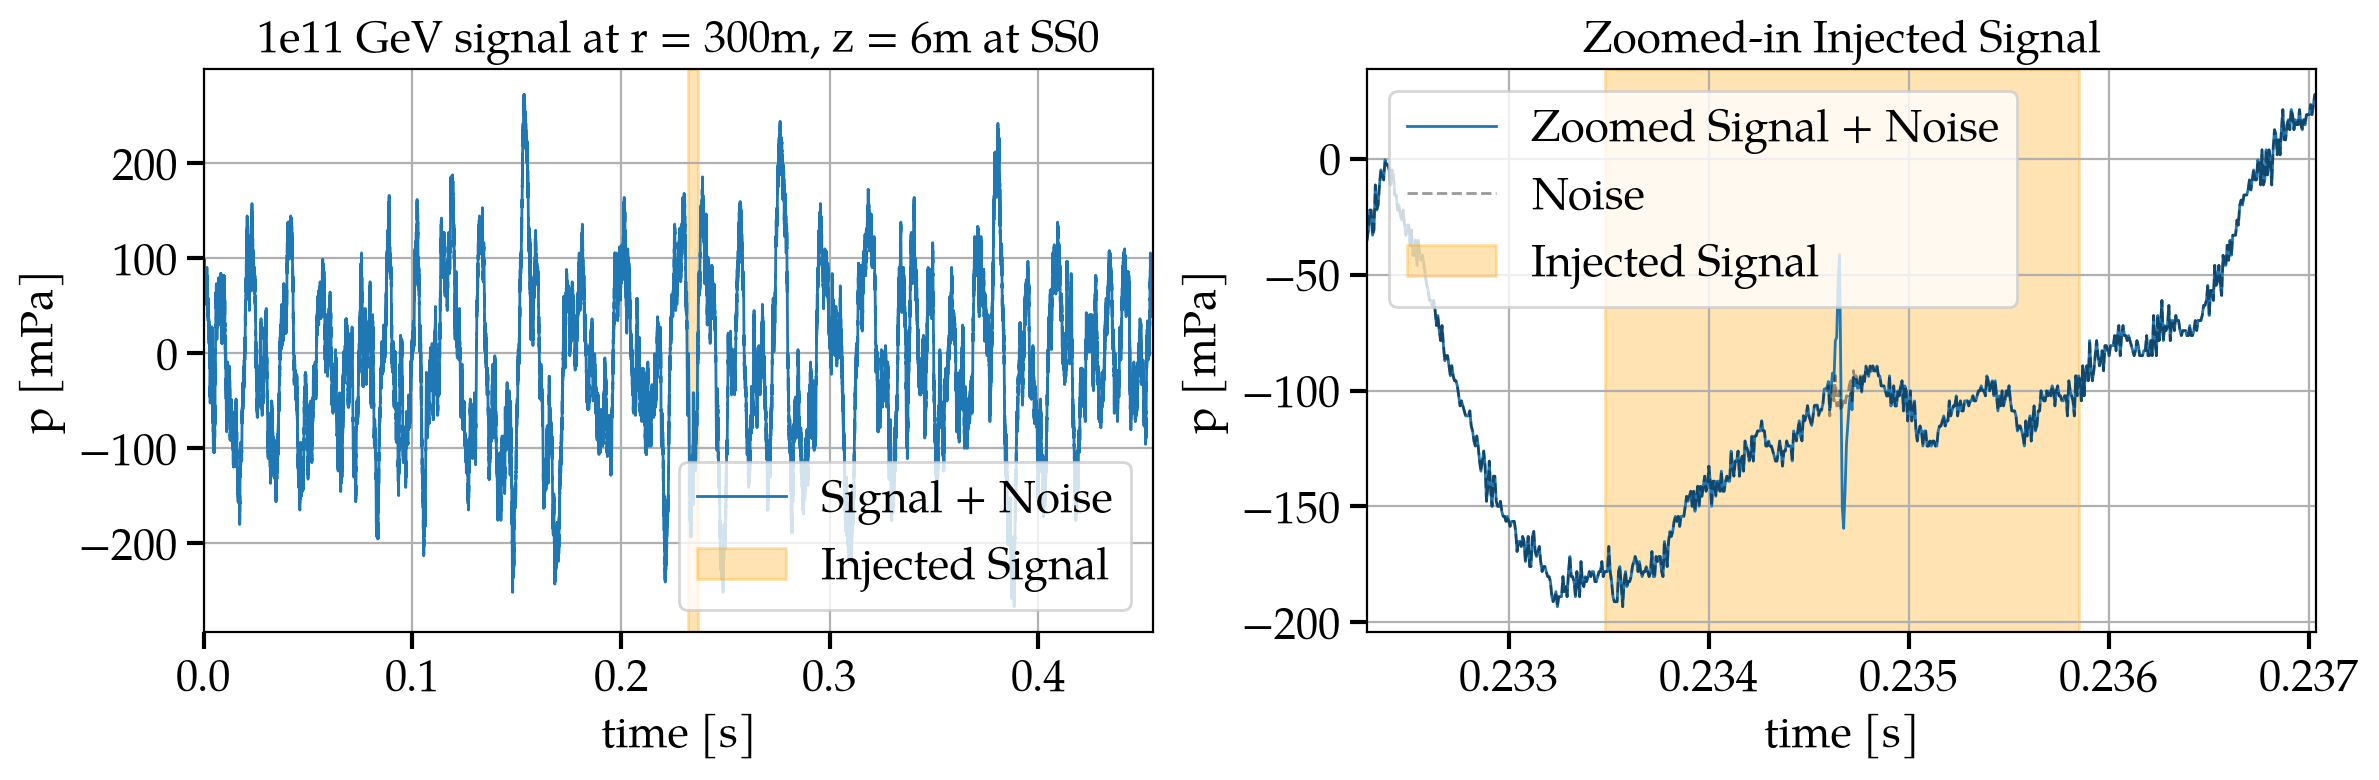

In [14]:
np.random.seed(62)
SSt = 0
from matplotlib import rcParams
rcParams["lines.linewidth"] = 1
neutrino = np.loadtxt("../matched_filter/data_files/template_1e11_6_1000")
print(neutrino.shape)
t = neutrino[:,0]
p = neutrino[:,1]
plot_offset = len(t)//3
length_sample = int(2**16)
startind_signal = length_sample // 2

# Obtain randomised noise
tb, background = PyT.random_subtrace_ss(seastate=SSt, times_series=y, length=length_sample, sampling_rate=144e3)
neutrino_signal = np.zeros_like(background)
neutrino_signal += background
neutrino_signal[startind_signal:startind_signal+len(p)] += p

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: full signal + noise
ax1.plot(tb, neutrino_signal*1e3, label="Signal + Noise")
ax1.grid()
ax1.set_title(f"1e11 GeV signal at r = 300m, z = 6m at SS{SSt}")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("p [mPa]")
highlight_start = tb[startind_signal+ plot_offset] 
highlight_end = tb[startind_signal+len(p)-1- plot_offset] 
ax1.axvspan(highlight_start, highlight_end, color='orange', alpha=0.3, label="Injected Signal")
ax1.legend(loc="lower right")
ax1.set_xlim(tb[0], tb[-1])

# Right: zoomed in on injected signal
zoom_mask         = (tb >= highlight_start) & (tb <= highlight_end)
tb_zoomed         = tb[zoom_mask]
signal_zoomed     = neutrino_signal[zoom_mask]*1e3
background_zoomed = background[zoom_mask]*1e3

ax2.plot(tb_zoomed, signal_zoomed, label="Zoomed Signal + Noise")
ax2.plot(tb_zoomed, background_zoomed, '--k' ,label="Noise", alpha=0.4)
ax2.grid()
ax2.set_xlabel("time [s]")
ax2.set_ylabel("p [mPa]")
ax2.set_title("Zoomed-in Injected Signal")
ax2.axvspan(tb[startind_signal + 5*len(p)//12], tb[startind_signal + 7*len(p)//12], color='orange', alpha=0.3, label="Injected Signal")
ax2.legend(loc="upper left")
ax2.set_xlim(tb_zoomed[0], tb_zoomed[-1])

plt.tight_layout()


# Phase scrambling
Phase scrambling is the approach favoured in previous work. In this method, the data is first phase-scrabled and then scaled.

It is important to note that for this method to be valid, the noise must be **fully uncorrelated**

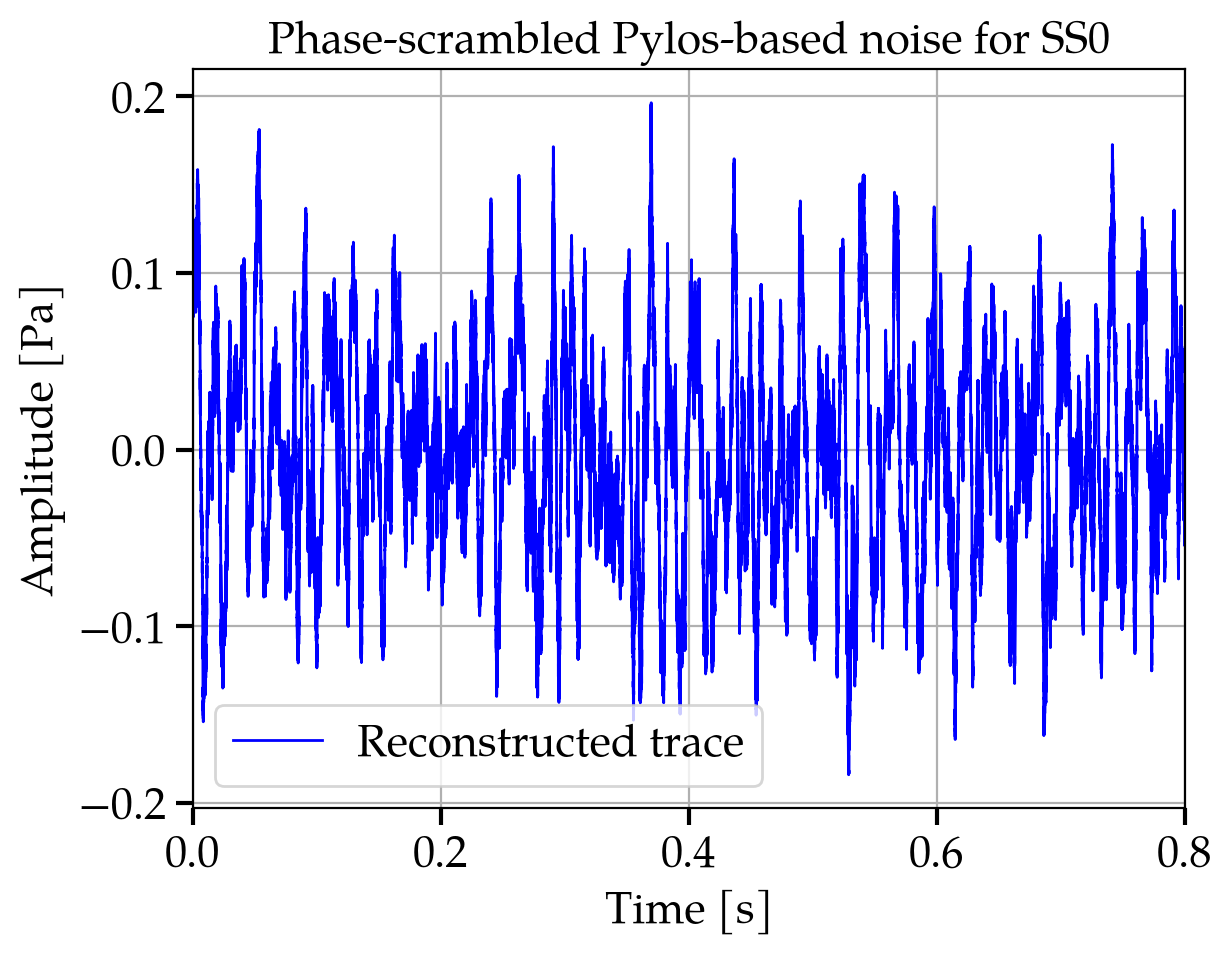

In [15]:
SSr = 0
length_sample = int(2**17)

# grab beginning part of the data
y0 = y_FFT[:length_sample]

t0, mock_noise = PyT.random_scrambled_trace_ss(y0, SSr, sample_frequency=sampling_rate, method='Welch')

plt.subplots()
# plt.plot(t, y, 'g-', label='Original trace')
plt.title(f'Phase-scrambled Pylos-based noise for SS{SSr}')
plt.plot(t0, mock_noise, 'b-', label='Reconstructed trace')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude [Pa]')
plt.xlim(0,0.8)
plt.legend()
plt.grid()
plt.show()
    